# 📊 Telecom Customer Churn Analysis

**Dataset:** Telco Customer Churn (Kaggle)  
**Goal:** Discover why customers leave a telecom company and present actionable business insights.

---

## Project Steps
1. Load and explore the data
2. Answer key business questions
3. Visualize patterns
4. Summarize findings

> **Before running:** Place `WA_Fn-UseC_-Telco-Customer-Churn.csv` inside the `../data/` folder.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set a clean visual style for all plots
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## Step 2: Load the Dataset

In [2]:
# Load the CSV from the data folder
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset shape: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3: Basic Data Exploration

In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Check for missing values in each column
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# TotalCharges is stored as string - fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows where TotalCharges is NaN (brand-new customers with 0 tenure)
df.dropna(subset=['TotalCharges'], inplace=True)

print(f'Clean dataset shape: {df.shape}')

Clean dataset shape: (7032, 21)


In [6]:
# Churn distribution
print('Churn value counts:')
print(df['Churn'].value_counts())
print()
print('Churn percentage:')
print(df['Churn'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Churn value counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.42%
Yes    26.58%
Name: proportion, dtype: object


## Step 4: Business Questions

We'll answer 4 key questions:
1. What is the overall churn rate?
2. Do month-to-month customers churn more?
3. Do higher charges lead to more churn?
4. Does customer tenure affect churn?

In [7]:
# Q1: Overall churn rate
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print('Overall Churn Rate:')
print(churn_rate.round(2))

Overall Churn Rate:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


In [8]:
# Q2: Churn rate by contract type
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).mul(100).round(2).unstack()
print('Churn Rate by Contract Type (%):')
print(contract_churn)

Churn Rate by Contract Type (%):
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85


In [9]:
# Q3: Average monthly charges for churned vs retained customers
avg_charges = df.groupby('Churn')['MonthlyCharges'].mean().round(2)
print('Average Monthly Charges by Churn Status:')
print(avg_charges)

Average Monthly Charges by Churn Status:
Churn
No     61.31
Yes    74.44
Name: MonthlyCharges, dtype: float64


In [10]:
# Q4: Average tenure for churned vs retained customers
avg_tenure = df.groupby('Churn')['tenure'].mean().round(2)
print('Average Tenure (months) by Churn Status:')
print(avg_tenure)

Average Tenure (months) by Churn Status:
Churn
No     37.65
Yes    17.98
Name: tenure, dtype: float64


## Step 5: Visualizations

We will create 4 charts and save them to the `../charts/` folder.

### Chart 1: Churn Rate by Contract Type (Percentage-Based)

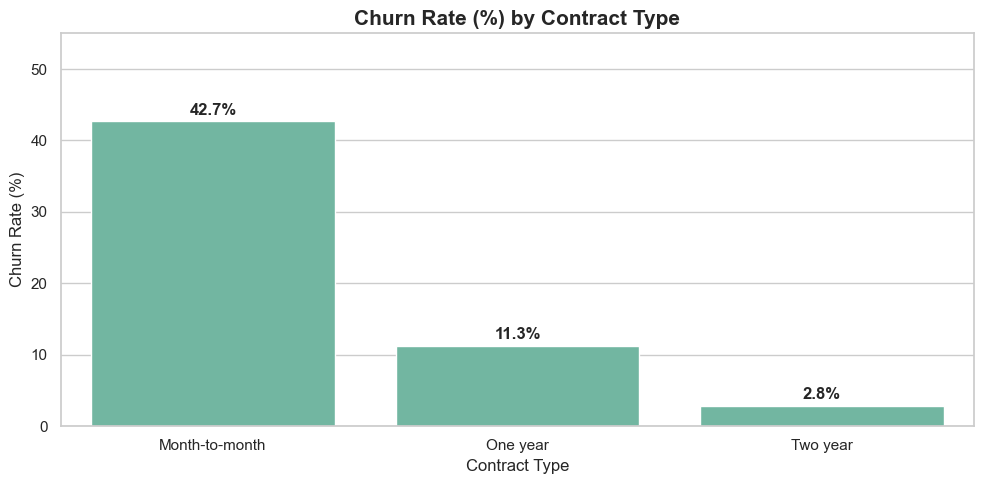

✅ Saved: churn_by_contract.png


In [11]:
# Build a percentage-based churn rate per contract type
# This is fairer than raw counts because there are different numbers of customers per contract
contract_churn_pct = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
contract_churn_pct.columns = ['Contract', 'Churn Rate (%)']

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=contract_churn_pct, x='Contract', y='Churn Rate (%)', ax=ax)
ax.set_title('Churn Rate (%) by Contract Type', fontsize=15, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)

# Add value labels on each bar
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('../charts/churn_by_contract.png', dpi=150)
plt.show()
print('✅ Saved: churn_by_contract.png')

> **Interpretation:** Month-to-month customers churn at ~43% compared to just ~11% for one-year and ~3% for two-year contract holders — making contract type the strongest single predictor of churn in this dataset. A customer on a flexible contract is 14x more likely to leave than one on a two-year agreement.

### Chart 2: Monthly Charges vs Churn

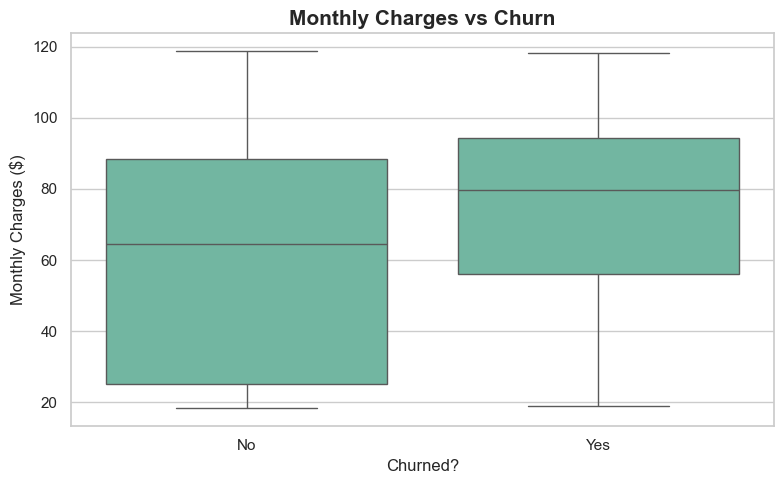

✅ Saved: monthly_charges_vs_churn.png


In [12]:
# Boxplot: shows median, spread, and outliers in one view
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax)
ax.set_title('Monthly Charges vs Churn', fontsize=15, fontweight='bold')
ax.set_xlabel('Churned?')
ax.set_ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('../charts/monthly_charges_vs_churn.png', dpi=150)
plt.show()
print('✅ Saved: monthly_charges_vs_churn.png')

> **Interpretation:** Customers who churned paid a median of ~$79/month compared to ~$65/month for retained customers — a $14 difference. This suggests that higher-cost plans (likely without long-term contracts) drive dissatisfaction, and that targeted retention offers for high-paying customers could significantly reduce churn.

### Chart 3: Churn Rate by Tenure Band

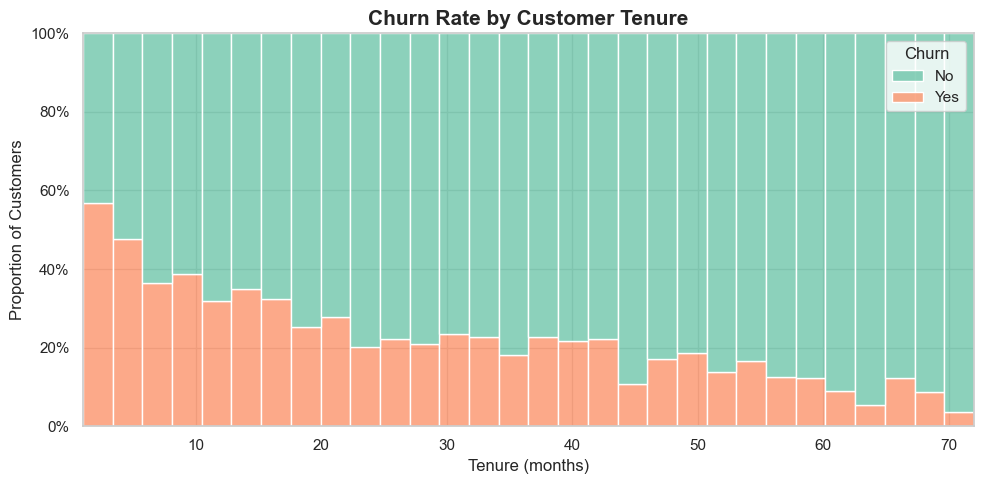

✅ Saved: tenure_vs_churn.png


In [13]:
# multiple='fill' shows the PROPORTION of churned vs retained at each tenure point
# This is more insightful than stacked bars which hide the rate behind raw counts
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, multiple='fill', ax=ax)
ax.set_title('Churn Rate by Customer Tenure', fontsize=15, fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Proportion of Customers')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y*100)}%'))
plt.tight_layout()
plt.savefig('../charts/tenure_vs_churn.png', dpi=150)
plt.show()
print('✅ Saved: tenure_vs_churn.png')

> **Interpretation:** Churn is heavily concentrated in the first 12 months — at month 1, nearly 60% of new customers churn. The rate drops sharply and stabilizes below 15% after month 24. This tells the business that the highest-risk window for losing a customer is the first year, making early onboarding and engagement critical.

### Chart 4: Churn Rate by Internet Service Type

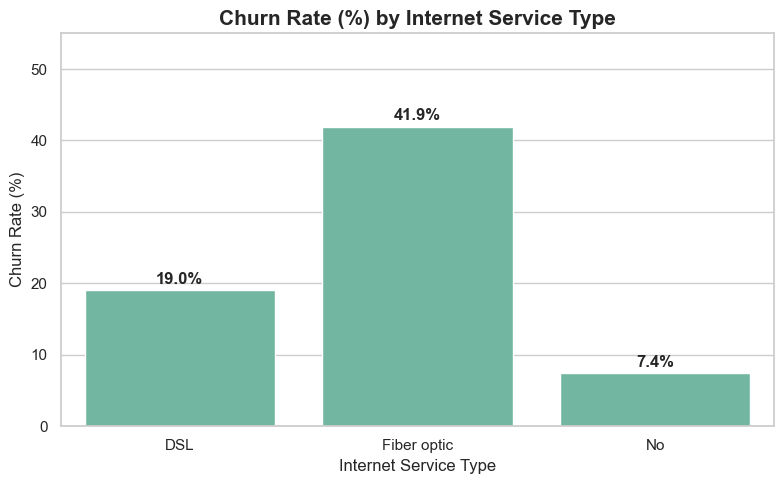

✅ Saved: churn_by_internet_service.png


In [14]:
# Replaces the pie chart — adds a new analytical dimension
# Internet service type reveals which product lines have the worst churn
internet_churn_pct = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
internet_churn_pct.columns = ['Internet Service', 'Churn Rate (%)']

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=internet_churn_pct, x='Internet Service', y='Churn Rate (%)', ax=ax)
ax.set_title('Churn Rate (%) by Internet Service Type', fontsize=15, fontweight='bold')
ax.set_xlabel('Internet Service Type')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)

# Add value labels
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('../charts/churn_by_internet_service.png', dpi=150)
plt.show()
print('✅ Saved: churn_by_internet_service.png')

> **Interpretation:** Fiber optic customers churn at ~42% — more than double the rate of DSL customers (~19%) and far above customers with no internet service (~7%). Despite being a premium product, fiber optic has a serious retention problem, likely driven by high monthly costs combined with month-to-month contracts. This is a clear product-level risk the business must address.

## Step 6: Key Findings Summary

Based on the analysis above, here are the 4 patterns we discovered:

| # | Finding | Insight |
|---|---------|--------|
| 1 | **Month-to-month churn ~43%** | Customers on flexible contracts churn far more — 14x higher than two-year customers |
| 2 | **Churned customers pay ~$14 more/month** | Higher charges correlate strongly with leaving |
| 3 | **60% of month-1 customers churn** | The first year is the highest-risk period — onboarding matters most |
| 4 | **Fiber optic churn at ~42%** | Premium internet service has a serious, product-level retention problem |

### Business Recommendation
> **Priority action 1:** Convert month-to-month customers to annual contracts within the first 3 months — offer a meaningful incentive.  
> **Priority action 2:** Investigate the fiber optic churn specifically — price sensitivity and service quality should both be examined.